In [3]:
!pip install control

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 578.3/578.3 kB 6.4 MB/s eta 0:00:00


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctrl
from control.matlab import *

# --- 1. Построение передаточной функции ---
# Мы начинаем с описания системы в частотной области (передаточная функция),
# потому что это позволяет сразу анализировать устойчивость и частотные свойства.

# Уравнение: y'' + 4y' + 6y = -u' - 2u
# После преобразования Лапласа получаем:
# W(s) = Y(s)/U(s) = (-s - 2) / (s^2 + 4s + 6)

num = [-1, -2]  # коэффициенты числителя (влияют на нули системы)
den = [1, 4, 6]  # коэффициенты знаменателя (влияют на полюса)

# Задаём передаточную функцию
w = tf(num, den)

print('Передаточная функция САУ:\n', w)
print("Полюса системы (определяют устойчивость):", pole(w))
print("Нули системы (влияют на форму отклика):", zero(w))


# --- 2. Преобразование в пространство состояний ---
# Это нужно, чтобы проводить более глубокий анализ (например, управляемость, наблюдаемость)
# и в дальнейшем дискретизировать систему для цифровой реализации.

sys_ss = ctrl.ss(w)
A, B, C, D = sys_ss.A, sys_ss.B, sys_ss.C, sys_ss.D

print("\nМодель в пространстве состояний (x' = Ax + Bu, y = Cx + Du):")
print("A =", A)  # матрица динамики
print("B =", B)  # как вход влияет на состояния
print("C =", C)  # как состояния влияют на выход
print("D =", D)  # прямая связь входа с выходом (обычно 0)
# --- Вывод об устойчивости непрерывной системы ---
# Устойчивость оценивается по положению полюсов (корней знаменателя передаточной функции):
# Если Re(λ) < 0 для всех полюсов → система устойчива

continuous_poles = pole(w)

# Проверка знаков вещественных частей полюсов
stable_continuous = all(np.real(p) < 0 for p in continuous_poles)

print("\nАнализ устойчивости непрерывной системы:")
print("Полюса:", continuous_poles)
if stable_continuous:
    print("Система устойчива, так как все полюса находятся в левой полуплоскости (Re < 0).")
else:
    print("Система неустойчива, так как есть полюса с неотрицательной вещественной частью.")


Передаточная функция САУ:
 <TransferFunction>: sys[0]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

     -s - 2
  -------------
  s^2 + 4 s + 6
Полюса системы (определяют устойчивость): [-2.+1.41421356j -2.-1.41421356j]
Нули системы (влияют на форму отклика): [-2.+0.j]

Модель в пространстве состояний (x' = Ax + Bu, y = Cx + Du):
A = [[-4. -6.]
 [ 1.  0.]]
B = [[1.]
 [0.]]
C = [[-1. -2.]]
D = [[0.]]

Анализ устойчивости непрерывной системы:
Полюса: [-2.+1.41421356j -2.-1.41421356j]
Система устойчива, так как все полюса находятся в левой полуплоскости (Re < 0).


In [5]:
# --- 3. Проверка управляемости и наблюдаемости ---
# Управляемость — можно ли перевести систему в любое состояние через вход
# Наблюдаемость — можно ли восстановить состояние, зная только выход

controllability_matrix = ctrb(A, B)
rank_controllability = np.linalg.matrix_rank(controllability_matrix)
is_controllable = rank_controllability == A.shape[0]

observability_matrix = obsv(A, C)
rank_observability = np.linalg.matrix_rank(observability_matrix)
is_observable = rank_observability == A.shape[0]

print("\nМатрица управляемости:\n", controllability_matrix)
print("Ранг:", rank_controllability)
print("Система управляема:", is_controllable)  # если True — это очень хорошо

print("\nМатрица наблюдаемости:\n", observability_matrix)
print("Ранг:", rank_observability)
print("Система наблюдаема:", is_observable)  # если True — можно строить наблюдатель



Матрица управляемости:
 [[ 1. -4.]
 [ 0.  1.]]
Ранг: 2
Система управляема: True

Матрица наблюдаемости:
 [[-1. -2.]
 [ 2.  6.]]
Ранг: 2
Система наблюдаема: True


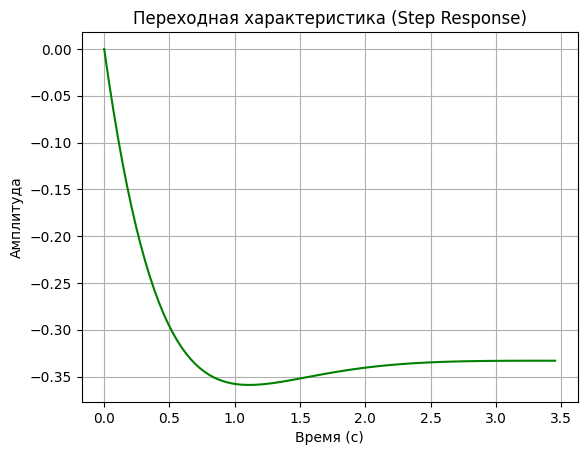

In [6]:
# --- 4. Переходная характеристика ---
# Показывает реакцию системы на скачкообразный вход (u(t) = 1)
# Это важно, чтобы оценить стабильность, колебания, скорость реакции и перерегулирование

y, x = step(w)
plt.plot(x, y, "g")
plt.title('Переходная характеристика (Step Response)')
plt.ylabel('Амплитуда')
plt.xlabel('Время (с)')
plt.grid(True)
plt.show()


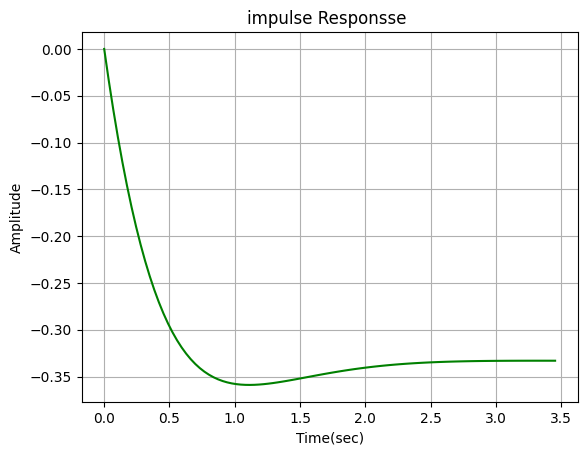

In [7]:
# --- 5. Импульсная характеристика ---
# Это реакция системы на мгновенное короткое воздействие (единичный импульс)
# Используется для анализа "внутреннего" поведения системы без накопления энергии y,x=impulse(w)
plt.plot(x,y,"g")
plt.title('impulse Responsse ')
plt.ylabel('Amplitude')
plt.xlabel('Time(sec)')
plt.grid(True)
plt.show()


/usr/local/lib/python3.12/dist-packages/control/freqplot.py:454: FutureWarning: bode_plot() return value of mag, phase, omega is deprecated; use frequency_response()
  warnings.warn(


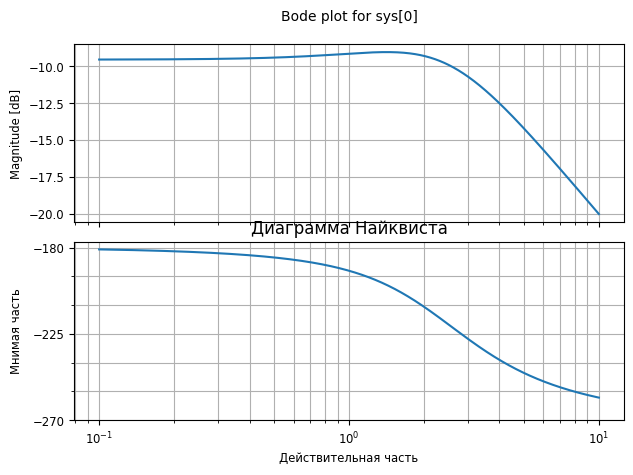

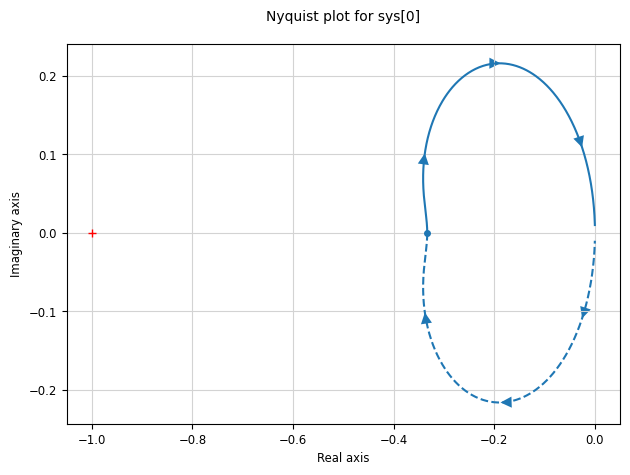

In [8]:
# --- 6. Частотные характеристики (Bode и Nyquist) ---
# Нужны для анализа устойчивости, частотной чувствительности и проектирования регуляторов

# Bode: показывает, как система усиливает или ослабляет сигналы разной частоты
mag, phase, omega = bode(w, dB=True)

# Nyquist: позволяет оценить устойчивость замкнутой системы и наличие резонансов
plt.title('Диаграмма Найквиста')
plt.xlabel('Действительная часть')
plt.ylabel('Мнимая часть')
nyquist(w)
plt.grid(True)
plt.show()


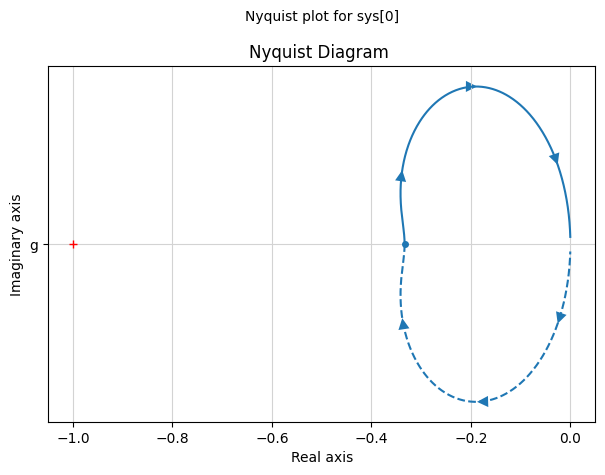

In [9]:
# Частотный годограф Найквиста
plt.title('Nyquist Diagram ')
plt.ylabel('Imaginary Axis')
plt.xlabel('Real Axis')
nyquist(w)
plt.grid(True)
plt.plot("g")
plt.show()


Непрерывная модель: 
<StateSpace>: sys[13]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']

A = [[-4. -6.]
     [ 1.  0.]]

B = [[1.]
     [0.]]

C = [[-1. -2.]]

D = [[0.]]
Полюса: 
[-2.+1.41421356j -2.-1.41421356j]


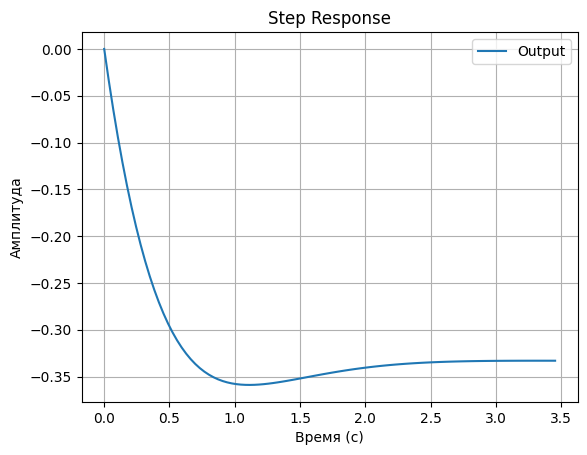

Дискретная модель: 
<StateSpace>: sys[13]$sampled
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']
dt = 0.1

A = [[ 0.64735621 -0.48960263]
     [ 0.08160044  0.97375796]]

B = [[0.08160044]
     [0.00437367]]

C = [[-1. -2.]]

D = [[0.]]
Полюса дискретной модели: 
[0.81055708+0.11540045j 0.81055708-0.11540045j]
Система устойчива


In [11]:
# Определение матриц системы A = np.array([[-4, -6], [1, 0]])
B = np.array([[1], [0]])
C = np.array([[-1, -2]])
D = np.array([[0]])

# Создание модели состояния
system = ctrl.ss(A, B, C, D)
print("Непрерывная модель: \n{}".format(system))

# Нахождение полюсов системы
poles = system.poles()
print("Полюса: \n{}".format(poles))

# Переходная характеристика для каждого выхода
t, y = ctrl.step_response(system)
plt.plot(t, y, label='Output')
plt.title('Step Response')
plt.ylabel('Амплитуда')
plt.xlabel('Время (с)')
plt.legend()
plt.grid(True)
plt.show()

# Дискретизация системы с шагом дискретизации h = 0.1
h = 0.1
sd = ctrl.c2d(system, h, method='zoh')
print("Дискретная модель: \n{}".format(sd))

# Нахождение полюсов дискретной модели
print("Полюса дискретной модели: \n{}".format(sd.poles()))

# Проверка устойчивости дискретной системы
stable = all(abs(p) < 1 for p in sd.poles())
print("Система устойчива" if stable else "Система неустойчива")


SISO дискретная модель: 
<StateSpace>: sys[15]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']
States (2): ['x[0]', 'x[1]']
dt = 0.1

A = [[ 0.64735621 -0.48960263]
     [ 0.08160044  0.97375796]]

B = [[0.08160044]
     [0.00437367]]

C = [[-1. -2.]]

D = [[0.]]


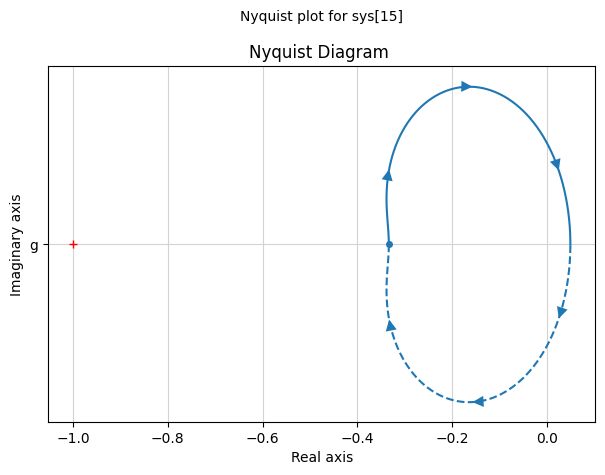

In [12]:
siso_system = ctrl.ss(sd.A, sd.B[:, 0], sd.C[0, :], sd.D[0, 0], sd.dt)
print("SISO дискретная модель: \n{}".format(siso_system))
# Частотный годограф Найквиста
plt.title('Nyquist Diagram ')
plt.ylabel('Imaginary Axis')
plt.xlabel('Real Axis')
nyquist(siso_system)
plt.grid(True)
plt.plot("g")
plt.show()


Полюсы дискретной системы: [0.81055708+0.11540045j 0.81055708-0.11540045j]
Дискретная система устойчива: True


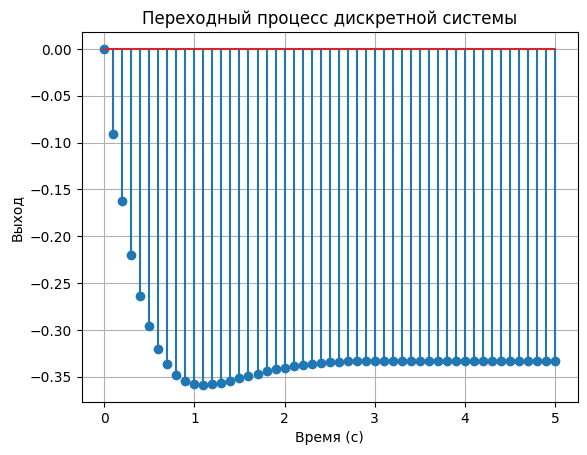

In [13]:
# Преобразование дискретной передаточной функции в состояние
Gd_ss = siso_system
T_s = 0.1

# Оценка устойчивости дискретной системы
poles_d = np.linalg.eigvals(Gd_ss.A)
print("Полюсы дискретной системы:", poles_d)
print("Дискретная система устойчива:", np.all(np.abs(poles_d) < 1))
t, y = ctrl.step_response(Gd_ss)
# Переходный процесс дискретной системы
plt.stem(t, y)
plt.title('Переходный процесс дискретной системы')
plt.xlabel('Время (с)')
plt.ylabel('Выход')
plt.grid()
plt.show()
